In [92]:
import pandas as pd
import folium

In [73]:
# dfs
df1 = pd.read_csv("afli_data1.csv")
df2 = pd.read_csv("afli_data2.csv")
df3 = pd.read_csv("afli_data3.csv")
afli_df = pd.concat([df1, df2, df3], ignore_index=True)

coords = pd.read_csv("iceland_towns_coordinates.csv")


In [74]:
# Drop the unnamed column
afli_df = afli_df.drop(columns=['Unnamed: 0'])

In [75]:
# Rename columns
afli_df = afli_df.rename(columns={
    'Fisktegund': 'Species',
    'Löndunarhöfn': 'Port',
    'Eining': 'Unit',
    'Ár': 'Year',
    'Mánuður': 'Month',
    'Afli og aflaverðmæti eftir fisktegund, löndunarhöfn, landsvæðum og mánuðum 1982-2024': 'Value'
})
# Translate Icelandic month names to English
month_map = {
    'janúar': 'January',
    'febrúar': 'February',
    'mars': 'March',
    'apríl': 'April',
    'maí': 'May',
    'júní': 'June',
    'júlí': 'July',
    'ágúst': 'August',
    'september': 'September',
    'október': 'October',
    'nóvember': 'November',
    'desember': 'December'
}
afli_df['Month'] = afli_df['Month'].map(month_map).fillna(afli_df['Month'])

In [76]:
# Replace '.' with NaN, then convert to numeric
afli_df['Value'] = afli_df['Value'].replace('.', pd.NA)
afli_df['Value'] = pd.to_numeric(afli_df['Value'], errors='coerce')

In [77]:
foreign_ports = [
    "A.-Þýskaland", "Bandaríkin", "Belgía", "Bretland", "Danmörk",
    "Domeniska lýðveldið", "Frakkland", "Færeyjar", "Grænland",
    "Holland", "Írland", "Japan", "Kanada", "Litháen", "Namibía",
    "Noregur", "Spánn", "Svíþjóð", "Tyrkland", "Þýskaland",
    "Önnur löndun"
]

afli_df = afli_df[~afli_df["Port"].isin(foreign_ports)]

In [78]:
afli_df

,Species,Port,Unit,Year,Month,Value
0,Þorskur,Akranes,Magn,1982,January,469.0
1,Þorskur,Akranes,Magn,1982,February,924.0
2,Þorskur,Akranes,Magn,1982,March,2262.0
3,Þorskur,Akranes,Magn,1982,April,1420.0
4,Þorskur,Akranes,Magn,1982,May,877.0
...,...,...,...,...,...,...
4167211,Annar afli,Þórshöfn,Verðmæti,2024,August,NaN
4167212,Annar afli,Þórshöfn,Verðmæti,2024,September,NaN
4167213,Annar afli,Þórshöfn,Verðmæti,2024,October,NaN
4167214,Annar afli,Þórshöfn,Verðmæti,2024,November,NaN


In [79]:
afli_by_teg = afli_df[afli_df["Unit"] == "Magn"].groupby("Species")["Value"].sum()

In [80]:
afli_by_teg_v = afli_df[afli_df["Unit"] == "Verðmæti"].groupby("Species")["Value"].sum()

In [81]:
afli_by_teg_v.sort_values(ascending=False).head(8)

Species
Þorskur    1.411495e+09
Ýsa        3.319531e+08
Karfi      2.794676e+08
Ufsi       2.013704e+08
Loðna      1.848594e+08
Grálúða    1.794316e+08
Makríll    1.677618e+08
Rækja      1.173878e+08
Name: Value, dtype: float64

In [82]:
afli_by_teg.sort_values(ascending=False).head(8)

Species
Loðna                 20780551.0
Þorskur               10085783.0
Kolmunni               5728245.0
Norsk-íslensk síld     3623711.0
Síld                   3606282.0
Karfi                  2619519.0
Makríll                2385192.0
Ufsi                   2288157.0
Name: Value, dtype: float64

In [83]:
top_species_v = afli_by_teg_v.sort_values(ascending=False).head(8).index.tolist()
top_species = afli_by_teg.sort_values(ascending=False).head(8).index.tolist()
top_species_combined = list(set(top_species_v + top_species))

In [84]:
species = ["Þorskur", "Ýsa", "Loðna", "Síld", "Makríll"]

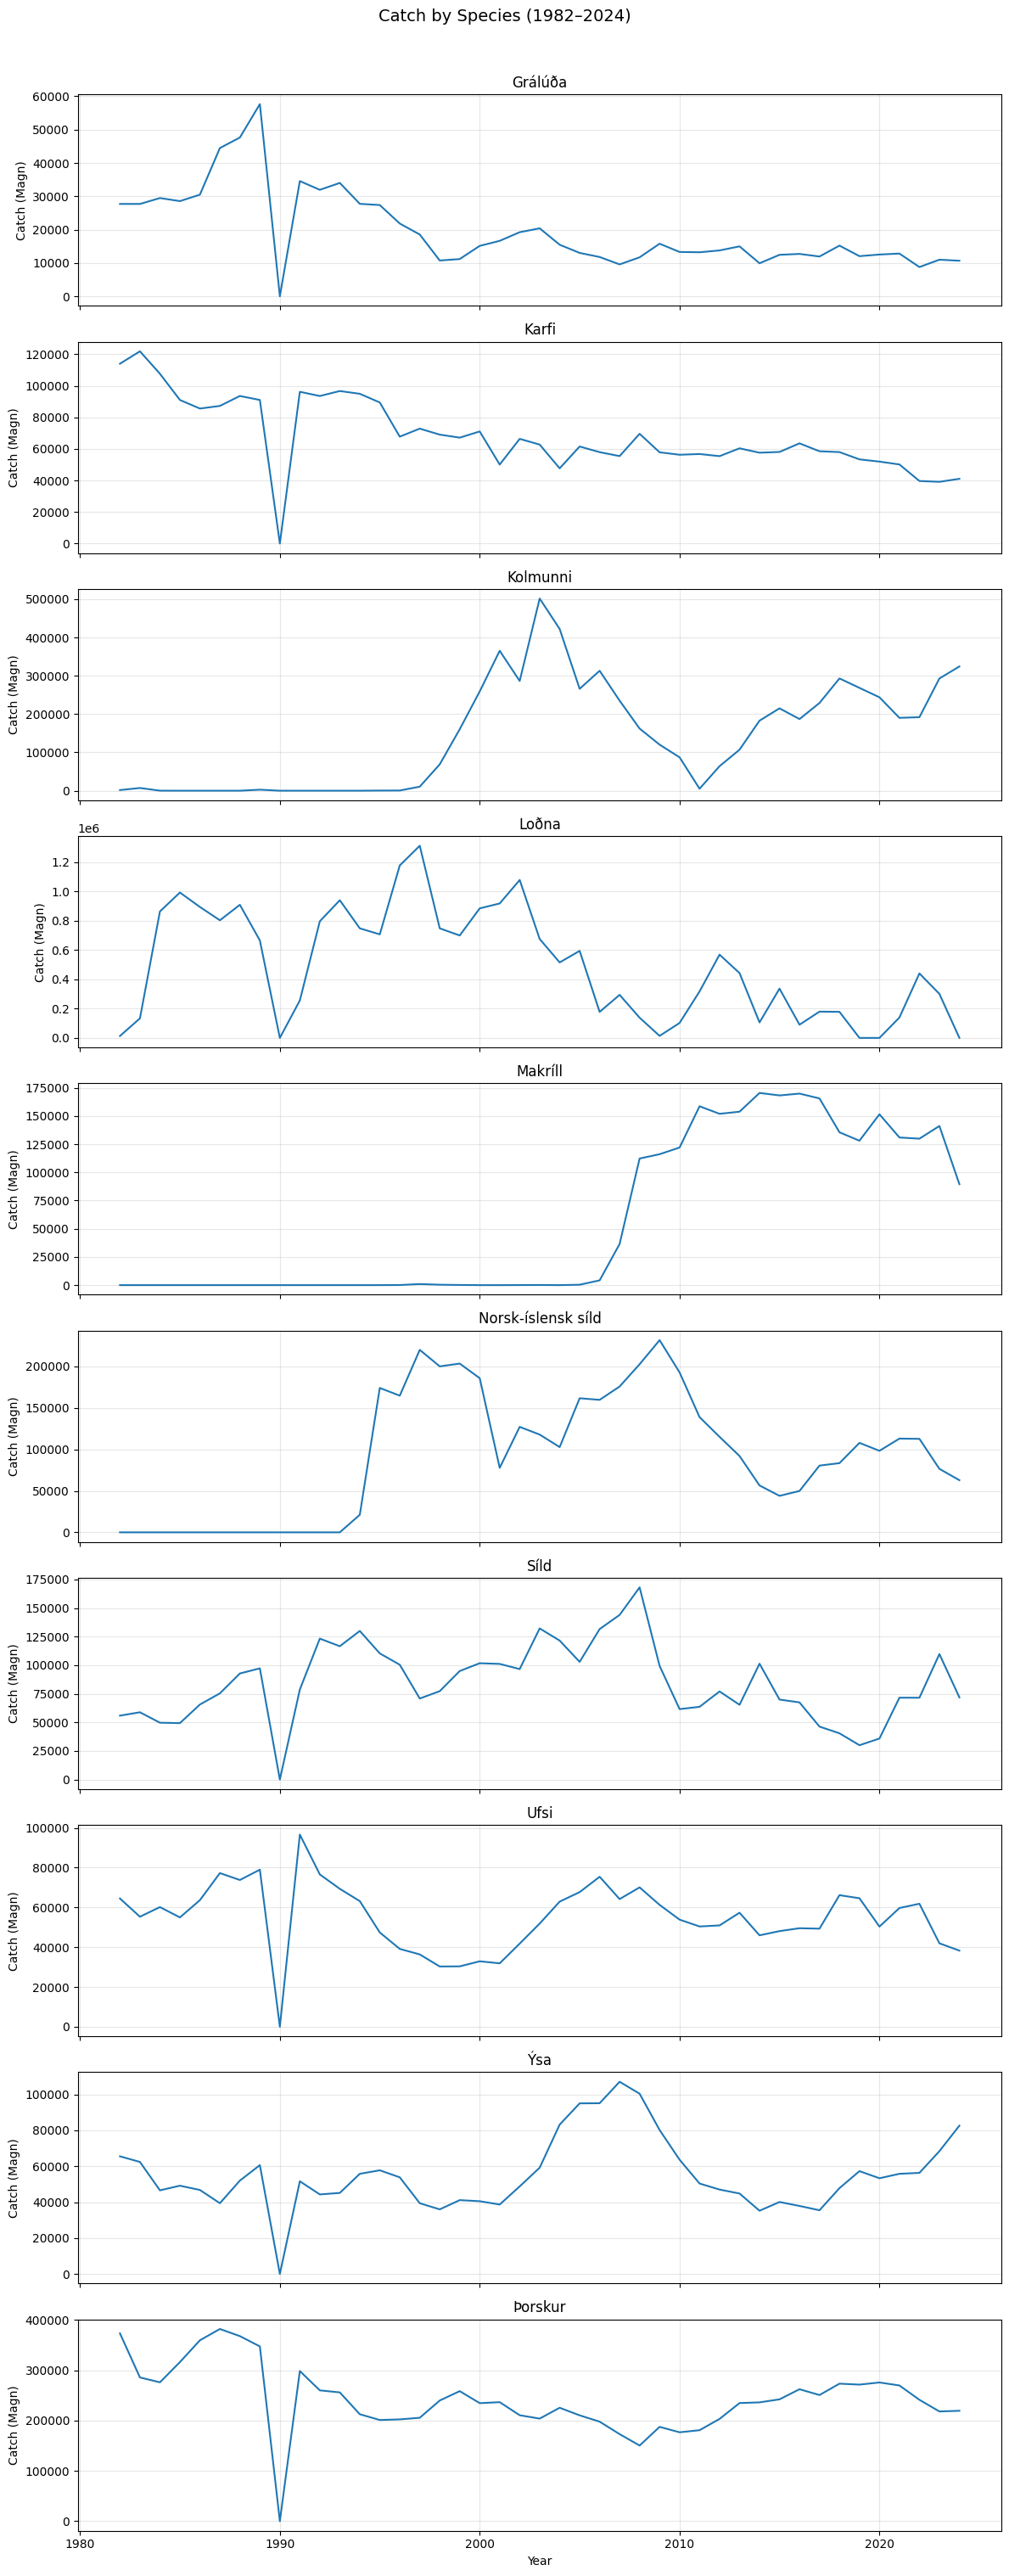

In [85]:
import matplotlib.pyplot as plt

species_list = sorted(plot_df["Species"].unique())
n = len(species_list)

fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

for ax, species in zip(axes, species_list):
    data = plot_df[plot_df["Species"] == species]
    ax.plot(data["Year"], data["Value"])
    ax.set_ylabel("Catch (Magn)")
    ax.set_title(species)
    ax.grid(True, alpha=0.3)

plt.xlabel("Year")
plt.suptitle("Catch by Species (1982–2024)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [86]:
afli_hafnir = afli_df[afli_df["Unit"] == "Magn"].groupby("Port")["Value"].sum()

In [90]:
# top 3 ports
top_ports = afli_hafnir.sort_values(ascending=False).head(30).index.tolist()

In [88]:
afli_hafnir.sort_values(ascending=False).head(30)

Port
Vestmannaeyjar     6795125.0
Neskaupstaður      6520954.0
Eskifjörður        4414780.0
Reykjavík          3764702.0
Seyðisfjörður      3586312.0
Grindavík          2831391.0
Vopnafjörður       2661667.0
Siglufjörður       2339881.0
Akranes            2255178.0
Hornafjörður       2219066.0
Akureyri           2188764.0
Þórshöfn           1917971.0
Fáskrúðsfjörður    1507772.0
Hafnarfjörður      1205898.0
Raufarhöfn         1038756.0
Sandgerði          1024252.0
Þorlákshöfn         992666.0
Keflavík            954880.0
Bolungarvík         928050.0
Ísafjörður          805011.0
Reyðarfjörður       776291.0
Grundarfjörður      644652.0
Dalvík              605928.0
Djúpivogur          586471.0
Sauðárkrókur        585853.0
Ólafsvík            535140.0
Rif                 456111.0
Skagaströnd         450167.0
Ólafsfjörður        439879.0
Patreksfjörður      307843.0
Name: Value, dtype: float64

In [101]:
# single year
year = 2015

# Filter: year 2023, Unit Magn, top ports, selected species
map_df = afli_df[
    (afli_df["Year"] == year) &
    (afli_df["Unit"] == "Magn") &
    (afli_df["Port"].isin(top_ports)) &
    (afli_df["Species"].isin(top_species_combined))
]

# Aggregate by port
port_totals = map_df.groupby("Port")["Value"].sum().reset_index()

# Merge with coordinates
port_totals = port_totals.merge(coords, left_on="Port", right_on="town", how="inner")

# Scale radius — adjust the divisor to taste
max_val = port_totals["Value"].max()
port_totals["radius"] = (port_totals["Value"] / max_val) * 30

m = folium.Map(location=[65.0, -18.5], zoom_start=6, tiles="CartoDB positron")

for _, row in port_totals.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["radius"],
        color="#185FA5",
        fill=True,
        fill_color="#185FA5",
        fill_opacity=0.7,
        popup=f"<b>{row['Port']}</b><br>Catch: {row['Value']:,.0f}",
        tooltip=f"{row['Port']}: {row['Value']:,.0f}",
    ).add_to(m)

m.save("iceland_catch_map_2023.html")
m